In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
df = pd.read_csv("public/processed_wind_dataset.csv")

df.head()

,startTime,generation_actual,generation_forecast
0,2024-01-01 00:00:00,10402,11453.0
1,2024-01-01 00:30:00,10845,NaN
2,2024-01-01 01:00:00,11218,11838.0
3,2024-01-01 01:30:00,11223,NaN
4,2024-01-01 02:00:00,11234,12090.0


In [11]:
df["error"] = df["generation_actual"] - df["generation_forecast"]

In [21]:
mean_error = round(df["error"].mean(), 2)
median_error = round(df["error"].median(), 2)
p99_error = round(df["error"].quantile(0.99), 2)

print("Mean Error:", mean_error)
print("Median Error:", median_error)
print("P99 Error:", p99_error)

Mean Error: -1179.51
Median Error: -928.0
P99 Error: 2959.83


In [ ]:
'''The forecast error analysis shows a mean error of 
-1179 MW, indicating that forecasts tend to slightly overestimate wind generation on average. The median error of 
-928 MW confirms this systematic bias. The P99 error of 2959 MW highlights occasional large deviations, likely caused
by sudden changes in wind conditions. Overall, while the forecasts capture the general trend of wind generation, 
significant variability remains, especially during high wind volatility periods.'''

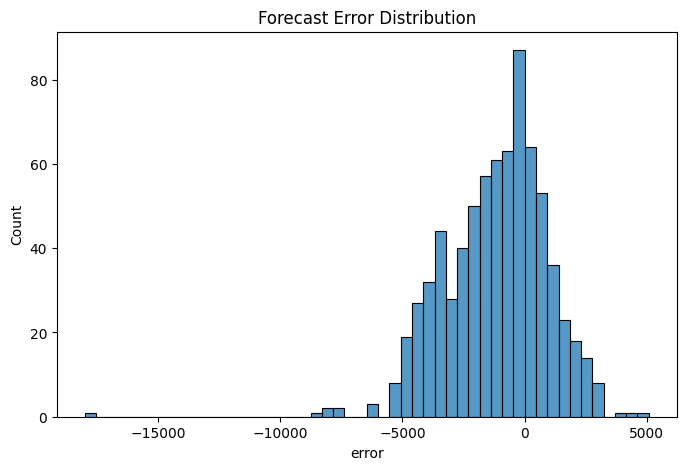

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(data=df.dropna(subset=["error"]), x="error", bins=50)
plt.title("Forecast Error Distribution")
plt.show()

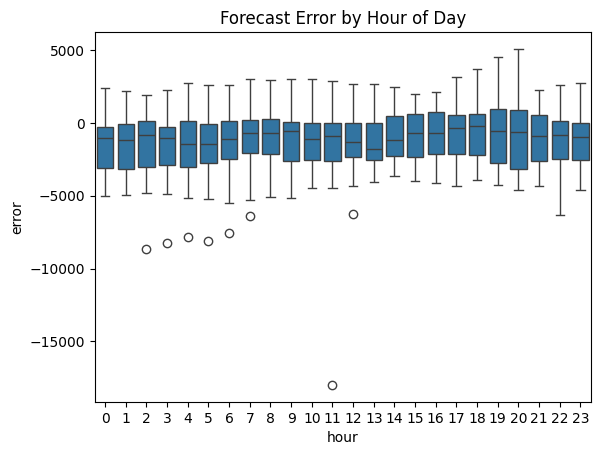

In [14]:
df["hour"] = pd.to_datetime(df["startTime"]).dt.hour

sns.boxplot(x="hour", y="error", data=df)
plt.title("Forecast Error by Hour of Day")
plt.show()

In [16]:
df_actual = pd.read_csv("C:\\freelance\\reit\\wind-forecast-app\\public\\actual_wind_generation_jan2024.csv")

In [17]:
df_actual["generation_actual"].describe()

count     1536.000000
mean      9906.540365
std       3640.096830
min          0.000000
25%       6769.750000
50%      10130.500000
75%      13032.750000
max      16662.000000
Name: generation_actual, dtype: float64

In [18]:
df_actual["generation_actual"].quantile(0.1)
df_actual["generation_actual"].quantile(0.2)

np.float64(6321.0)

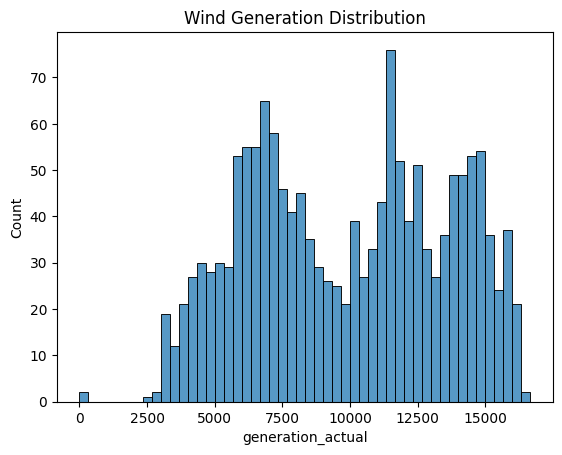

In [19]:
sns.histplot(df_actual["generation_actual"], bins=50)
plt.title("Wind Generation Distribution")
plt.show()

In [ ]:
''' Based on the analysis of the January wind generation data and forecast errors, wind power output shows
significant variability across time. The distribution indicates that generation ranges widely, from very low values
to peaks above 16,000 MW, with an average of about 9,900 MW and a median near 10,130 MW. This suggests that
wind generation is moderately stable around the median but still subject to large fluctuations. The forecast error
analysis across hours shows noticeable variability and occasional large outliers, indicating that prediction accuracy
changes throughout the day. Overall, while forecasts capture general trends reasonably well, uncertainty
remains significant, highlighting the importance of conservative planning when relying on wind generation 
for electricity supply.'''
